In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

df = pd.read_csv('monthly_demand_clean.csv', index_col=0, parse_dates=True)
df.index.name = 'Month'
print(df.shape)
df.head()

(54, 5)


,CPU,Mother Board,RAM,Storage,Video Card
Month,,,,,
2013-06-01,NaN,NaN,NaN,119.0,NaN
2013-07-01,NaN,NaN,NaN,0.0,NaN
2013-08-01,NaN,NaN,NaN,0.0,NaN
2013-09-01,NaN,NaN,NaN,0.0,NaN
2013-10-01,NaN,NaN,NaN,0.0,NaN


In [2]:
df.describe()          # min, max, mean per category
df.isna().sum()         # any leftover missing values per category
df.sum().sort_values(ascending=False)   # total demand by category — which product line is biggest

Storage         4943.0
CPU             4851.0
Video Card      2964.0
Mother Board    2880.0
RAM             1189.0
dtype: float64

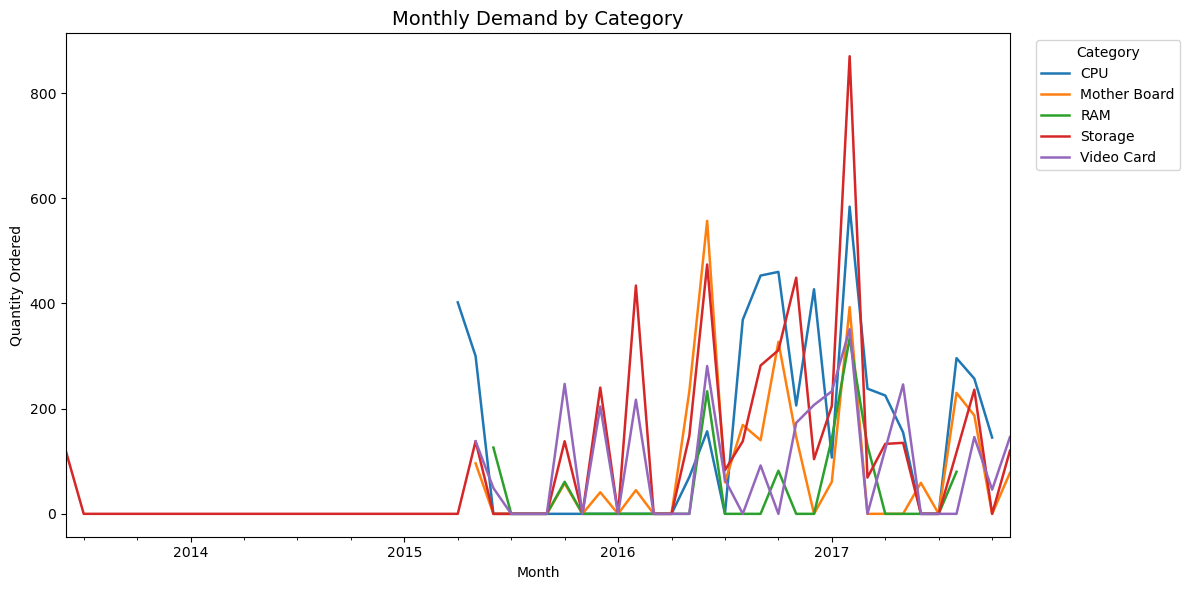

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
df.plot(ax=ax, linewidth=1.8)
ax.set_title('Monthly Demand by Category', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Quantity Ordered')
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

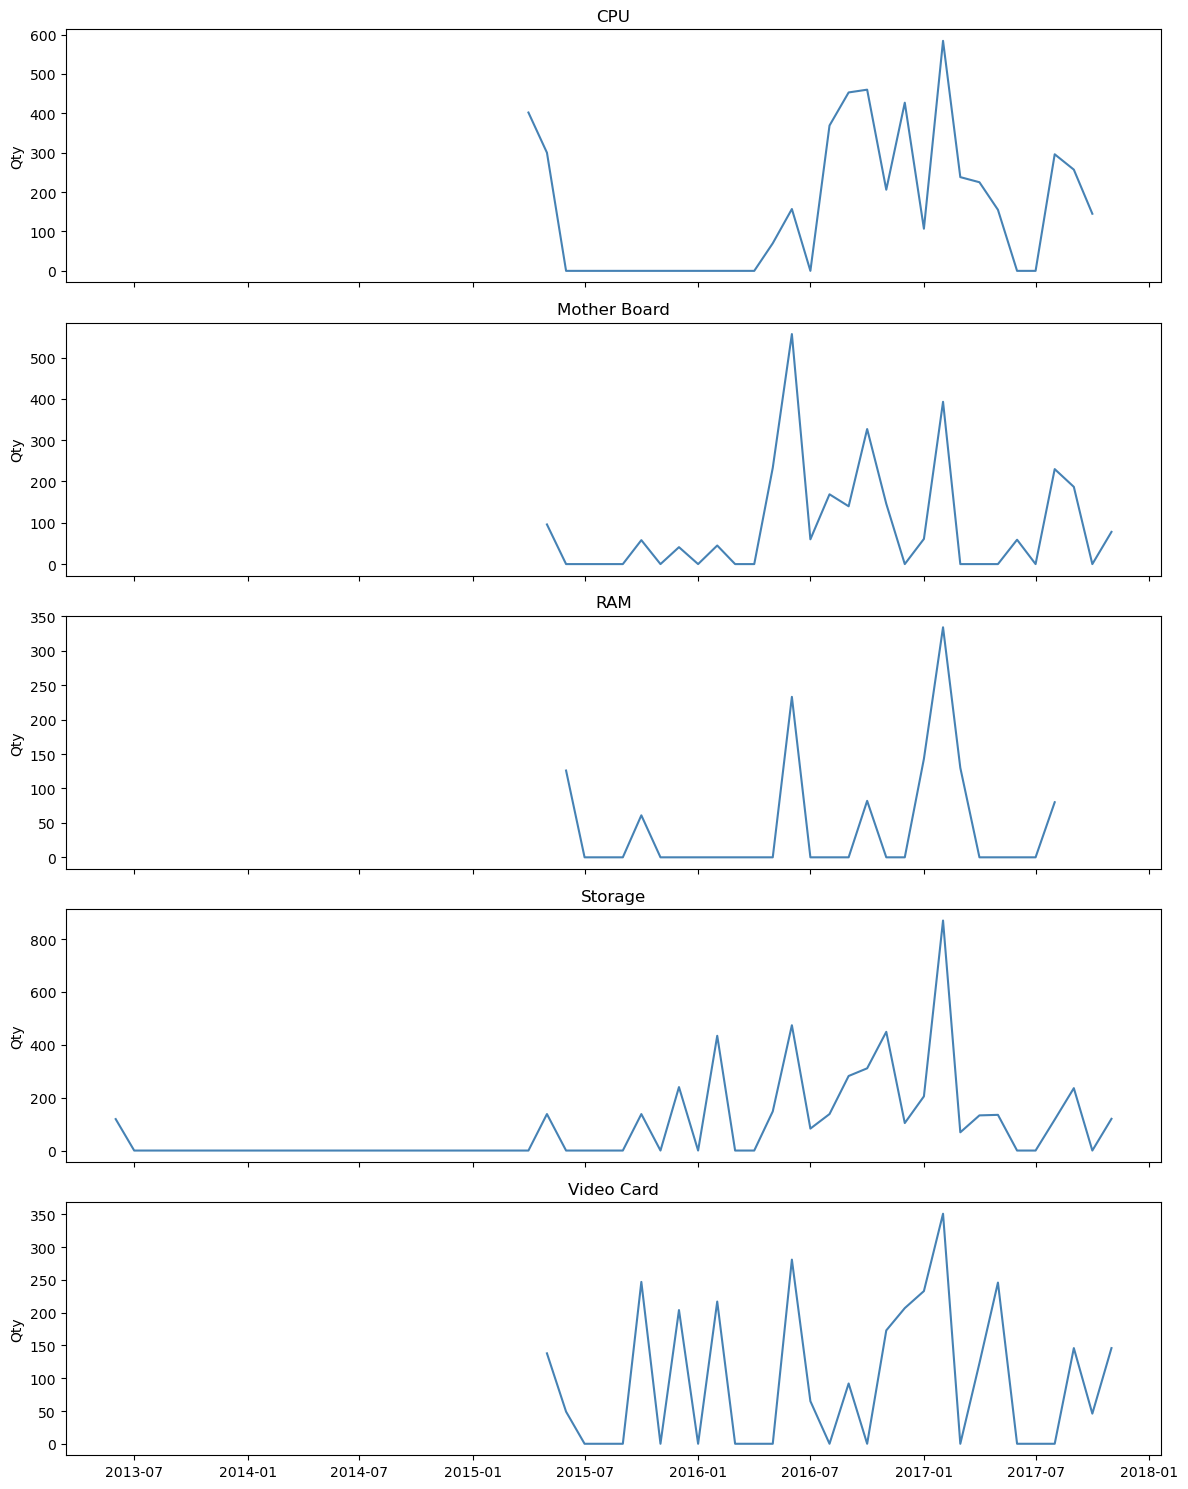

In [4]:
categories = df.columns.tolist()
fig, axes = plt.subplots(len(categories), 1, figsize=(12, 3*len(categories)), sharex=True)

for ax, cat in zip(axes, categories):
    ax.plot(df.index, df[cat], color='steelblue')
    ax.set_title(cat)
    ax.set_ylabel('Qty')

plt.tight_layout()
plt.show()

In [15]:
import io

sample_data = """Month,Category,Value,IsAnomaly
2017-02-01,CPU,586,True
2017-08-01,Storage,880,True
"""

anomalies = pd.read_csv(io.StringIO(sample_data), parse_dates=['Month'])
anomalies.head()

,Month,Category,Value,IsAnomaly
0,2017-02-01,CPU,586,True
1,2017-08-01,Storage,880,True


In [19]:
print(anomalies.dtypes)
anomalies.head()

Month        object
Category     object
Value        object
IsAnomaly    object
dtype: object


,Month,Category,Value,IsAnomaly


In [20]:
anomalies['IsAnomaly'] = anomalies['IsAnomaly'].astype(bool)

In [21]:
anom_points = anomalies[anomalies['IsAnomaly'] == True]
anom_points

,Month,Category,Value,IsAnomaly


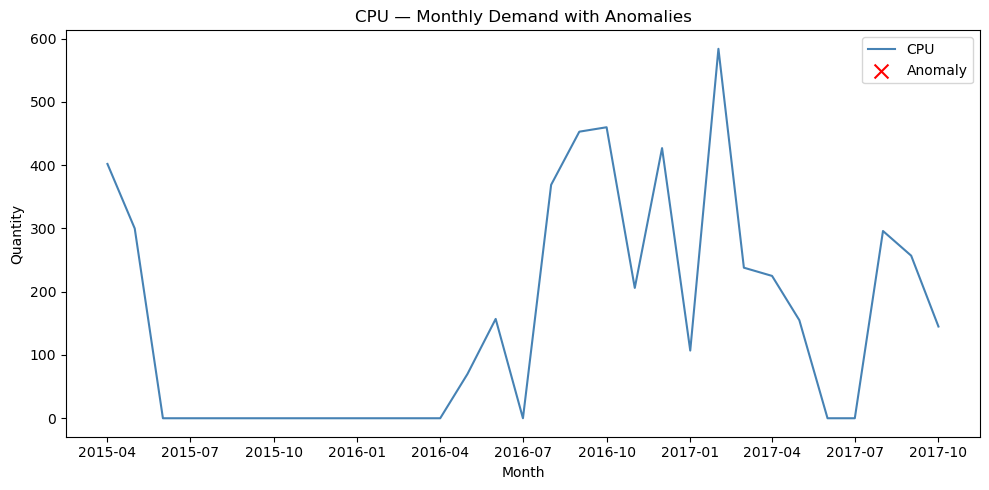

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

# the full trend line
ax.plot(df.index, df['CPU'], color='steelblue', linewidth=1.5, label='CPU')

# overlay only CPU's anomaly points
cpu_anom = anom_points[anom_points['Category'] == 'CPU']
ax.scatter(cpu_anom['Month'], cpu_anom['Value'], color='red', marker='x', s=100, label='Anomaly', zorder=5)

ax.set_title('CPU — Monthly Demand with Anomalies')
ax.set_xlabel('Month')
ax.set_ylabel('Quantity')
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
import matplotlib.pyplot as plt

def plot_category_trend(df, category, anomalies=None, figsize=(10, 4)):
    """Plot demand trend for one category, with anomaly points overlaid if provided."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df.index, df[category], color='steelblue', linewidth=1.5, label=category)

    if anomalies is not None and not anomalies.empty:
        cat_anom = anomalies[(anomalies['Category'] == category) & (anomalies['IsAnomaly'] == True)]
        ax.scatter(cat_anom['Month'], cat_anom['Value'], color='red', marker='x', s=80, label='Anomaly', zorder=5)

    ax.set_title(f'{category} — Monthly Demand')
    ax.set_xlabel('Month')
    ax.set_ylabel('Quantity')
    ax.legend()
    fig.tight_layout()
    return fig

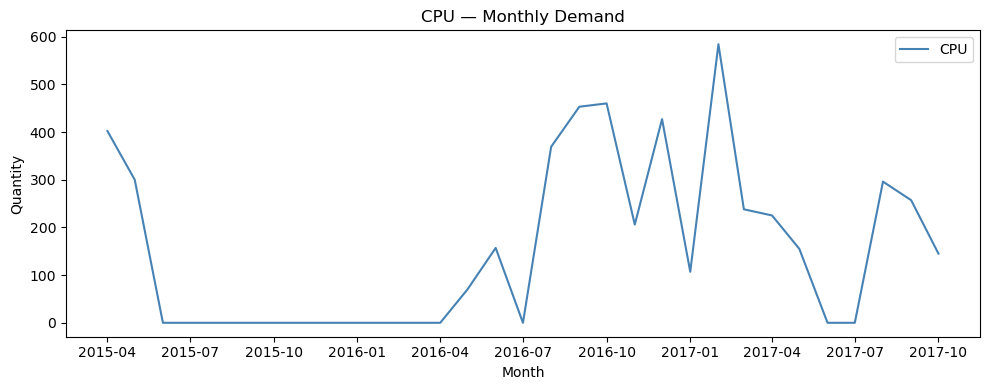

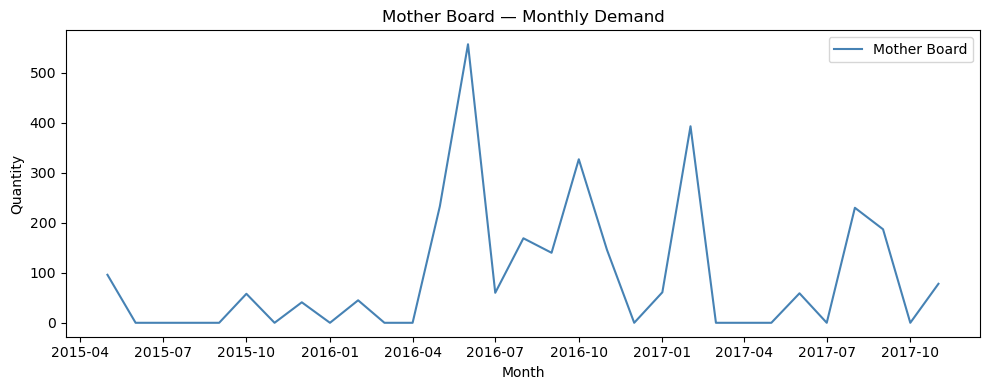

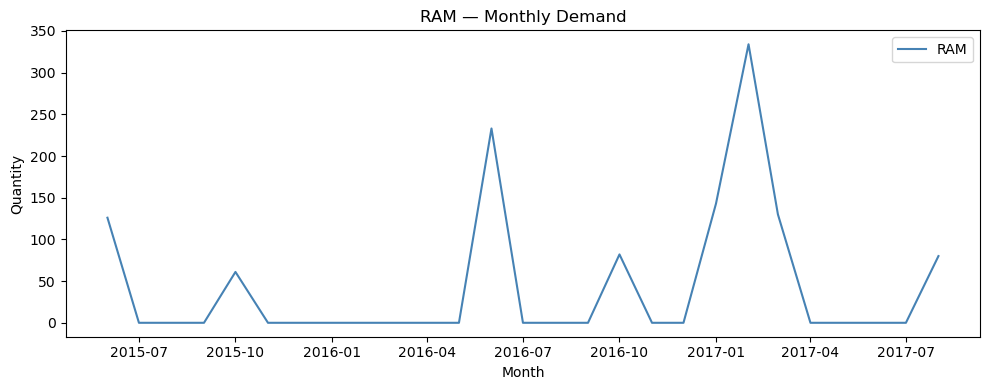

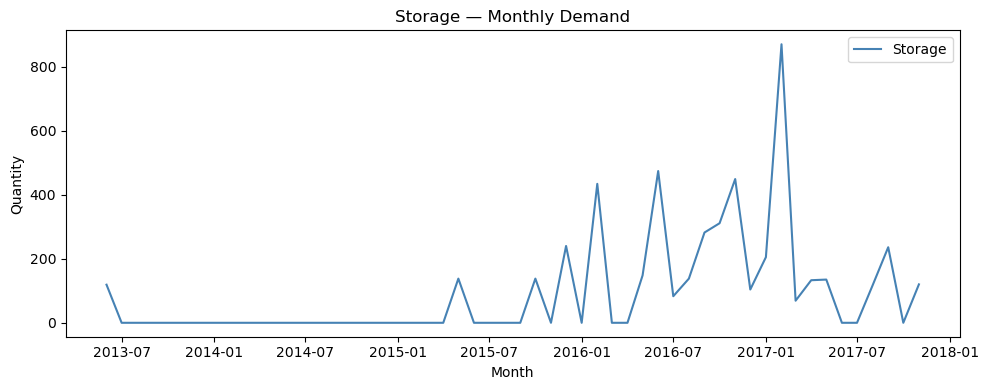

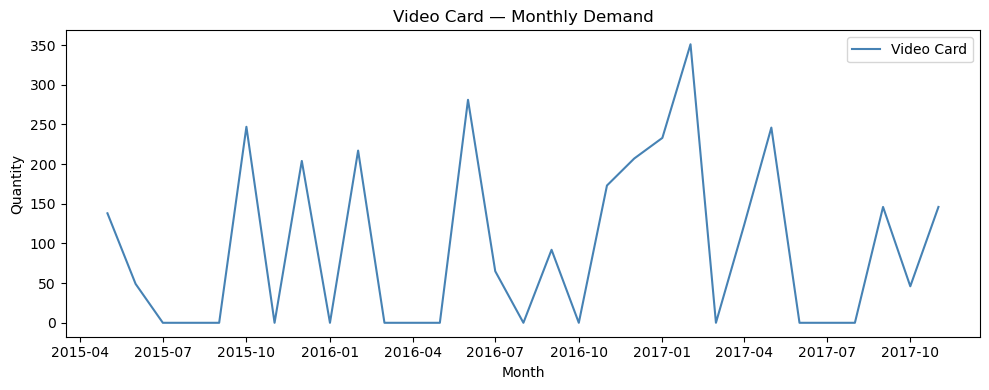

In [25]:
for cat in df.columns:
    fig = plot_category_trend(df, cat, anomalies)
    plt.show()